# Bridge Condition Modelling for Infrastructure Asset Management

An applied regression and exploratory analytics project using Texas bridge data to identify the structural and operational factors most associated with bridge condition.

## Overview

This notebook analyses bridge-condition data to identify which characteristics are most strongly associated with overall structural condition and how well a multiple linear regression model can predict condition at network scale.

The workflow includes target construction, data preparation, exploratory analysis, regression modelling, residual diagnostics, and practical interpretation for infrastructure asset management.

## Notebook Structure

This notebook is organised into five parts:

1. **Data loading and target construction**  
   Prepare the raw bridge dataset, derive a continuous condition target, and review data quality.

2. **Data preparation and feature engineering**  
   Create bridge age, simplify sparse material and design categories, and define the final modelling dataset.

3. **Exploratory analysis**  
   Examine how bridge condition varies with age, traffic, material, and design, and review relationships between predictors.

4. **Regression modelling and diagnostics**  
   Fit a multiple linear regression, evaluate model performance, and inspect residual behaviour.

5. **Interpretation, limitations, and implications**  
   Summarise what matters most for bridge condition, explain what the model can and cannot tell us, and discuss how the results could support maintenance prioritisation.

## Problem Statement

Bridge owners need evidence on which characteristics are most useful for prioritising maintenance and monitoring deterioration across large infrastructure networks.

This project investigates whether bridge age, traffic volume, truck intensity, material, and design can explain meaningful variation in overall bridge condition, and whether a multiple linear regression model can provide a useful decision-support tool for asset management.

## Data and Target Construction

The dataset contains bridge characteristics together with condition ratings for major structural components. To create a single modelling target, deck, superstructure, and substructure ratings are treated as integer scores and combined into a continuous `Condition_score`.

This creates a practical summary measure of bridge condition that can be analysed using regression, while still preserving meaningful variation across bridges.

The analysis then focuses on five candidate predictors:

- `Age`
- `AverageDaily`
- `Trucks_percent`
- `Material`
- `Design`

These variables were selected to represent a mix of structural, operational, and usage-related factors that may help explain differences in bridge condition.

## Section 1 – Data Preparation

**Aims and outline**

This section prepares the Texas bridge dataset for analysis by ensuring that all variables are correctly defined, clean, and ready for statistical modelling. The data are loaded and organised, appropriate data types are assigned (including ordered categorical variables), and additional variables are derived to capture key aspects of each bridge.

**Specifically, this section aims to:**

* Load the Texas bridge dataset and assigns correct variable types, including ordinal condition ratings for deck, superstructure, and substructure.  
* Derive a continuous **Condition_score** by combining the three component condition ratings.  
* Simplify categorical variables such as *Material* and *Design* by merging rare categories into broader groups to improve model stability.  
* Create an **Age** variable (years since construction) and exclude very old or historic bridges that could bias the analysis.  
* Review variable distributions and identify any potential extreme or implausible values to confirm data quality.
* Prepare a final dataset that is clean, complete and ready for modelling.

Together, these steps ensure that the dataset is comprehensive, consistent, and suitable for both exploratory and regression analysis in the sections that follow.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### 1.1: Load the Dataset and Define Variable Types

Before any analysis, the dataset was imported with each variable explicitly assigned an appropriate data type. This ensures that bridge characteristics (such as *Material* and *Design*) are recognised as categorical rather than numerical values. For the bridge condition variables, ordered categories were defined to reflect the inspection grading scales used by Texas Department of Transportation. The three condition ratings (*Deck*, *Superstructure*, *Substructure*) share the same ordered scale ranging from **“Failed”** to **“Excellent”**.

This structured loading preserves the intended meaning of each field and allows comparisons between bridges to respect the order of their official condition ratings.

In [ ]:
# Define categorical data types with specific orderings
# This one is for the general condition rating variables
rating_type = pd.CategoricalDtype(
    categories=['Failed', 'Failing', 'Critical', 'Serious', 'Poor', 'Fair',
                'Satisfactory', 'Good', 'Very Good', 'Excellent', 'NA'],
    ordered=True)

# This one is for the scour condition rating variable
scour_type = pd.CategoricalDtype(
    categories=['Unknown', 'Critical','Unstable', 'Stable', 'Protected', 'Dry', 'No waterway'],
    ordered=True)

# Define the data types for each column in the dataset
types_dict = { 'Structure_id': str, 'District':'category', 'Toll':'category',
              'Maintainer':'category', 'Urban':'category', 'Status':'category',
              'Historic':'category', 'Service_under':'category', 'Material':'category',
              'Design':'category',
              'Deck_rating':rating_type, 'Superstr_rating':rating_type, 'Substr_rating':rating_type,
              'Scour_rating':scour_type}

# Load the dataset with specified data types and set Structure_id as the index
bridges = pd.read_csv('tx19_bridges_sample.csv', dtype = types_dict, index_col = 'Structure_id')

# Display dataset information and first few rows
bridges.info()
bridges.head()

<class 'pandas.core.frame.DataFrame'>
Index: 34293 entries, 000021521-00101 to DAPTRABLI000011
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   District         34293 non-null  category
 1   Detour_Km        34293 non-null  int64   
 2   Toll             34293 non-null  category
 3   Maintainer       34293 non-null  category
 4   Urban            34293 non-null  category
 5   Status           34293 non-null  category
 6   Year             34293 non-null  int64   
 7   Lanes_on         34293 non-null  int64   
 8   Lanes_under      34293 non-null  int64   
 9   AverageDaily     34293 non-null  int64   
 10  Historic         34293 non-null  category
 11  Service_under    34293 non-null  category
 12  Material         34293 non-null  category
 13  Design           34293 non-null  category
 14  Spans            34293 non-null  int64   
 15  Length           34293 non-null  float64 
 16  Width            3429

,District,Detour_Km,Toll,Maintainer,Urban,Status,Year,Lanes_on,Lanes_under,AverageDaily,...,Spans,Length,Width,Deck_rating,Superstr_rating,Substr_rating,Rated_load,Trucks_percent,Scour_rating,Future_traffic
Structure_id,,,,,,,,,,,,,,,,,,,,,
000021521-00101,District2,199,Free,Agency,Rural,Local,2005,1,0,1,...,2,31.4,4.3,Good,Very Good,Very Good,41.7,0.0,Dry,1
000021521-00181,District2,199,Free,Agency,Rural,Local,2005,1,0,1,...,1,15.5,4.3,Good,Good,Very Good,41.7,0.0,Dry,1
000021521-TMP20,District2,199,Free,Agency,Rural,Local,2012,2,0,100,...,1,10.1,8.4,Very Good,Very Good,Very Good,48.1,0.0,Dry,150
000021525-00012,District2,199,Free,Agency,Rural,Local,1950,1,0,80,...,14,45.4,3.7,Good,Good,Poor,10.0,0.0,Dry,120
000021580-00092,District2,6,Free,Agency,Rural,Local,2004,2,0,150,...,1,25.0,7.3,Good,Very Good,Very Good,37.2,4.0,Dry,200


The summary confirms that all variables were imported successfully, with over 34,000 bridge records. Categorical variables such as *Material* and *Design* were correctly recognised, and the three main condition ratings were loaded as ordered categories. A very small number of missing values are seen in the condition ratings, which will be handled in the following part.

In [ ]:
# Check rows with missing values in Deck_rating and Superstr_rating
bridges.loc[(bridges.Deck_rating.isnull()) | (bridges.Superstr_rating.isnull()) ]

,District,Detour_Km,Toll,Maintainer,Urban,Status,Year,Lanes_on,Lanes_under,AverageDaily,...,Spans,Length,Width,Deck_rating,Superstr_rating,Substr_rating,Rated_load,Trucks_percent,Scour_rating,Future_traffic
Structure_id,,,,,,,,,,,,,,,,,,,,,
010920004518118,District1,0,Free,State,Rural,Arterial,1970,2,2,7520,...,1,42.7,12.2,NaN,Good,Good,32.7,2.0,No waterway,10530
021200AA0205001,District2,11,Free,County,Rural,Local,1946,1,0,340,...,1,17.7,3.9,Good,NaN,Fair,11.8,0.0,Stable,390
031690AA0273001,District3,5,Free,County,Rural,Local,2008,2,0,20,...,1,12.2,7.2,NaN,Very Good,Very Good,32.7,0.0,Dry,40
121020B37610001,District12,2,Free,Town or City,Urban,Local,2008,2,0,100,...,1,15.2,8.2,NaN,Good,Good,32.7,0.0,Stable,150
131580AA0323001,District13,159,Free,County,Rural,Local,1999,1,0,60,...,1,8.5,6.0,NaN,Very Good,Good,32.7,0.0,Dry,100
190190102001006,District19,10,Free,State,Rural,Minor,1991,2,0,160,...,4,67.1,9.1,NaN,Good,Good,32.7,16.0,Dry,230
211090AA0348002,District21,6,Free,County,Rural,Local,1960,2,0,50,...,3,11.0,5.5,Failing,NaN,Poor,0.0,0.0,Stable,30


### 1.2: Derive a Continuous Variable for Bridge Condition

To represent the overall structural condition of each bridge with a single numerical measure, the three component ratings (*Deck*, *Superstructure* and *Substructure*) were converted from their inspection categories (“Failed” to “Excellent”) into an integer scale from 0 to 9. The combined **Condition Score** was then calculated as the sum of the three components (maximum = 27), providing a continuous indicator of overall bridge condition. The histogram below shows the distribution of the combined scores across the network.

As mentioned above, a small number of bridges (seven in total) had missing inspection ratings and were excluded to ensure that the combined measure are based on complete and consistent data.

Bridges left after missing condition data is removed: 34,286
count    34286.000000
mean        20.300239
std          2.004642
min          0.000000
25%         19.000000
50%         21.000000
75%         22.000000
max         27.000000
Name: Condition_score, dtype: float64


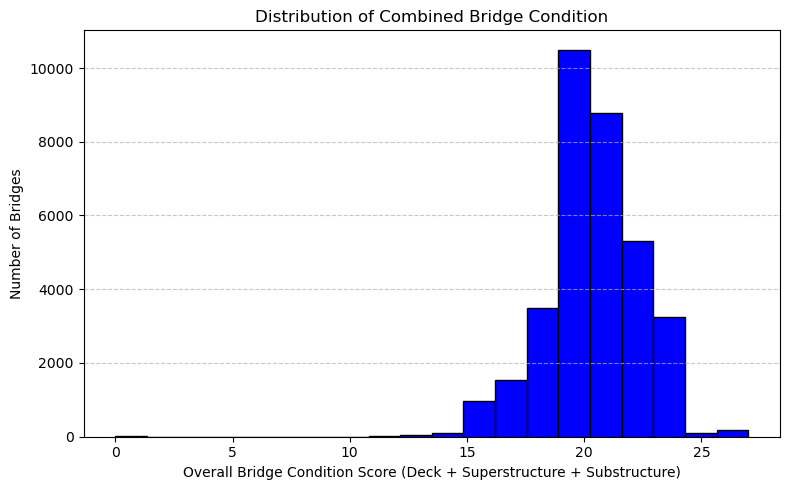

In [ ]:
# Define mapping from condition categories to numeric scores
rating_map = {
    "Failed": 0,
    "Failing": 1,
    "Critical": 2,
    "Serious": 3,
    "Poor": 4,
    "Fair": 5,
    "Satisfactory": 6,
    "Good": 7,
    "Very Good": 8,
    "Excellent": 9
}

# Apply mapping to each rating column
rating_cols = ["Deck_rating", "Superstr_rating", "Substr_rating"]
for col in rating_cols:
    bridges[col] = bridges[col].map(rating_map)

# Remove bridges with missing ratings (7 in total)
bridges = bridges.dropna(subset=rating_cols)
print(f"Bridges left after missing condition data is removed: {len(bridges):,}")

# Create combined condition score
bridges["Condition_score"] = (
    bridges["Deck_rating"] +
    bridges["Superstr_rating"] +
    bridges["Substr_rating"]
)

# Inspect summary and distribution
print(bridges["Condition_score"].describe())

plt.figure(figsize=(8, 5))
plt.hist(bridges["Condition_score"], bins=20, color="blue", edgecolor="black")
plt.title("Distribution of Combined Bridge Condition")
plt.xlabel("Overall Bridge Condition Score (Deck + Superstructure + Substructure)")
plt.ylabel("Number of Bridges")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()




**Results:** The summary confirms that almost all bridges have valid inspection data, with 34,286 records remaining after removing seven bridges that lacked one or more component ratings. The combined **Condition Score** ranges from 0 to 27, with an average value of about 20 and a median of 21. These values correspond to component ratings around **Good** on the inspection scale, indicating that most bridges are in generally **Good to Very good** structural condition, with only a small minority showing serious deterioration. The distribution of scores further supports this. Though slightly left-skewed, it shows a significant concentration of bridges with scores between 19 and 22. Only a very small number of bridges fall below 10, suggesting that severely deteriorated structures represent a minor fraction of the network.

From a data-quality perspective, this distribution is plausible for a managed state network. Most bridges are maintained in serviceable condition, while a small tail of low-scoring bridges highlights candidates for targeted maintenance or replacement. The derived continuous measure therefore provides a clear, quantitative basis for the subsequent regression analysis of factors influencing overall bridge condition.

### 1.3: Simplify Categorical Variables

Bridge *Material* and *Design* classifications were simplified to make the data more suitable for statistical analysis. Categories occurring in fewer than 200 bridges were combined into a single label **“Other”**. This reduction decreases sparsity in the data and helps ensure that the regression estimates for each remaining category are stable and interpretable.

The threshold of 200 bridges preserves the main construction types (for example, *Concrete* and *Beam*) while grouping very rare materials or specialised designs whose individual effects cannot be reliably estimated.
This balance retains essential engineering distinctions while preventing the analysis from being distorted by categories represented by only a handful of structures.

Materials reduced from 5 to 4 categories:
Material_simplified
Concrete    27123
Steel        6637
Timber        465
Other          61
Name: count, dtype: int64 

Designs reduced from 8 to 3 categories:
Design_simplified
Beam     28324
Slab      4340
Other     1622
Name: count, dtype: int64 



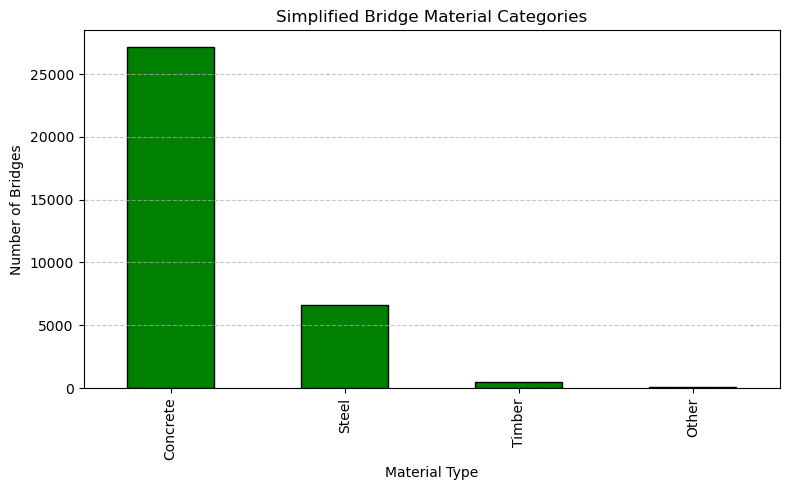

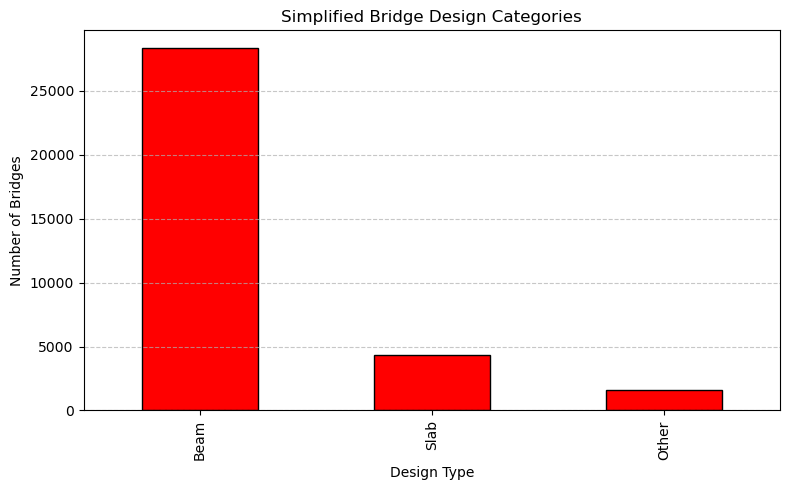

In [ ]:
# Identify rare categories
boundary = 200  # Categories with fewer than 200 occurrences will be grouped as "Other"
small_materials = bridges["Material"].value_counts()[lambda x: x < boundary].index
small_designs = bridges["Design"].value_counts()[lambda x: x < boundary].index

# Create simplified categories
bridges["Material_simplified"] = (
    bridges["Material"].astype(str).replace(small_materials.astype(str), "Other").astype("category")
)

bridges["Design_simplified"] = (
    bridges["Design"].astype(str).replace(small_designs.astype(str), "Other").astype("category")
)

# Display the value counts of the simplified categories
print(f"Materials reduced from {bridges['Material'].nunique()} to {bridges['Material_simplified'].nunique()} categories:")
print(bridges["Material_simplified"].value_counts(), "\n")
print(f"Designs reduced from {bridges['Design'].nunique()} to {bridges['Design_simplified'].nunique()} categories:")
print(bridges["Design_simplified"].value_counts(), "\n")

# Visualise the simplified categories
plt.figure(figsize=(8,5))
bridges["Material_simplified"].value_counts().plot(kind="bar", color="green", edgecolor="black")
plt.title("Simplified Bridge Material Categories")
plt.xlabel("Material Type")
plt.ylabel("Number of Bridges")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
bridges["Design_simplified"].value_counts().plot(kind="bar", color="red", edgecolor="black")
plt.title("Simplified Bridge Design Categories")
plt.xlabel("Design Type")
plt.ylabel("Number of Bridges")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

**Results:** The simplified categories show that the Texas network is dominated by bridges with concrete materials and beam design structures. **Concrete** is by far the most common construction material (>25,000), followed by steel, while timber and other materials are used only in a very small number of bridges. This pattern is consistent with the predominance of modern reinforced and prestressed concrete designs in state-managed highways.

Similarly, **beam** bridges account for the majority of structures(>25,000), with slab bridges forming a smaller but significant group. The small “Other” category consolidates several uncommon designs such as truss, arch, or culvert configurations.  

These simplified groupings retain the essential variation in bridge form while improving the stability of later statistical analysis. They provide a concise summary of how Texas bridges are typically built and therefore help interpret differences in condition by key structural type.

### 1.4: Create Bridge Age Variable and Exclude Historic Bridges

A new variable, **Age**, was created to represent the number of years since each bridge was constructed, using 2025 as the reference year. This enables direct comparison between bridge age and structural condition.

Although the dataset includes a categorical field *Historic* with values such as *Register* and *Possible*, these labels were found to be unreliable. Summary checks showed that some bridges marked as “historic” were built as recently as 2018, while most genuinely old bridges were constructed in the early twentieth century. To apply a more objective and reproducible rule, bridges aged **100 years or older** were excluded from the dataset. This removes truly historic structures while retaining any modern bridges that may have been misclassified.

By filtering on construction year rather than on the inconsistent *Historic* flag, the resulting dataset focuses on the bridges that form the active, operational network. This ensures that subsequent modelling reflects the performance of contemporary infrastructure rather than heritage assets maintained under different preservation standards.



Bridges removed (>=100 years old): 465
Remaining bridges: 33821
Summary of Bridge Age:
count    33821.000000
mean        42.672896
std         22.933749
min          6.000000
25%         23.000000
50%         39.000000
75%         60.000000
max         99.000000
Name: Age, dtype: float64


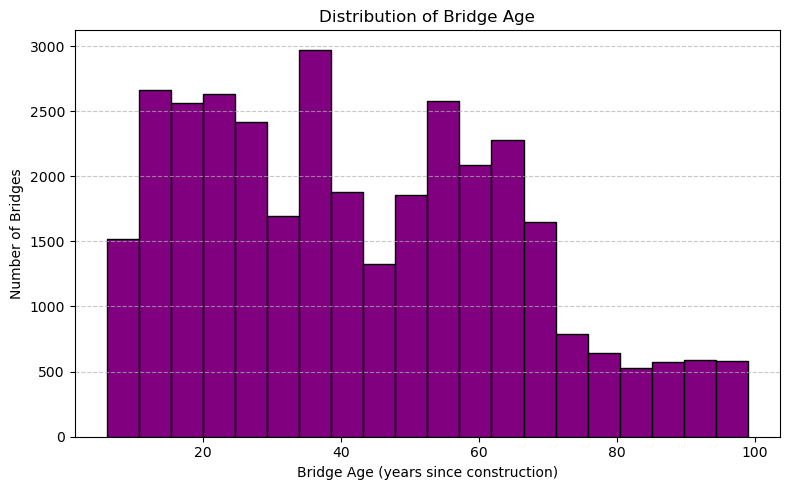

In [ ]:
# Calculate bridge ages
bridges["Age"] = 2025 - bridges["Year"]

# Remove very old bridges (>= 100 years)
initial_count = len(bridges)
bridges = bridges[bridges["Age"] < 100]
print(f"\nBridges removed (>=100 years old): {initial_count - len(bridges)}")
print(f"Remaining bridges: {len(bridges)}")

# Display summary statistics of bridge ages
print("Summary of Bridge Age:")
print(bridges["Age"].describe())

# Visualise the distribution of bridge ages
plt.figure(figsize=(8, 5))
plt.hist(bridges["Age"], bins=20, color="purple", edgecolor="black")
plt.title("Distribution of Bridge Age")
plt.xlabel("Bridge Age (years since construction)")
plt.ylabel("Number of Bridges")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

**Results:** The bridge age distribution shows a broad range from 6 to 99 years, with a mean of about 43 years and a median of 39 years. The histogram is **multi-modal**, with several peaks between approximately 20, 40 and 60 years. This probably reflect distinct phases of bridge construction and renewal projects in Texas — for example, the 1960s and 1970s saw significant bridge construction in Texas, largely driven by the expansion of the interstate highway system.

The sharp reduction beyond 70 years suggests that older structures have progressively been replaced, while the smaller number of very new bridge (under 10 years) represents recent construction. This age profile indicates that most bridges are **middle-aged**, which is advantageous as it provides a balanced representation of typical deterioration patterns. This enables the regression model to capture realistic ageing effects and produce predictions that are more relevant for the management of the Texas Department of Transportation.

### 1.5: Review of Extreme Values After Filtering

Before proceeding to exploratory analysis, the continuous predictors were examined for potential outliers or implausible entries. Summary statistics were calculated for **Age**, **AverageDaily** (average daily traffic), and **Trucks_percent** (percentage of heavy-goods vehicles), including the 1st and 99th percentiles. This check ensures that any extreme values reflect genuine bridge characteristics rather than data entry errors. For instance, unusually high traffic counts or truck percentages could distort regression estimates if left unchecked. Where extreme values appear plausible (for example, heavily used urban bridges), they are retained; where values seem unrealistic, they would be flagged for possible exclusion or transformation.

In [ ]:
# Summary statistics for Age, AverageDaily, and Trucks_percent
bridges[["Age", "AverageDaily", "Trucks_percent"]].describe(percentiles=[0.01, 0.99]).round(2)

,Age,AverageDaily,Trucks_percent
count,33821.00,33821.00,33821.00
mean,42.67,11736.78,8.59
std,22.93,24372.12,10.36
min,6.00,0.00,0.00
1%,8.00,10.00,0.00
50%,39.00,3320.00,5.00
99%,95.00,120404.00,43.00
max,99.00,543000.00,99.00


**Results:**

**Age:**  
Bridge ages range from 6 to 99 years, with a median of 39 years and a 99th percentile of 95 years. Since bridges aged 100 years or more were previously excluded, the observed range is consistent with expectations. This confirms that the age variable is realistic and free from implausible outliers.

**AverageDaily (traffic volume):**  
Average daily traffic is highly positively-skewed. The median bridge carries about 3,300 vehicles per day, whereas the mean (11,700) is inflated by a small number of very busy crossings. The upper 1 % of bridges exceed 120,000 vehicles per day, with a maximum of 543,000. These values are plausible for major urban or interstate bridges, so they represent genuine variability in network usage rather than data errors.

**Trucks_percent (heavy-goods vehicle share):**  
Truck percentages range from 0 % to 99 %, with a median of 5 % and a 99th percentile of 43 %. Most bridges carry relatively few trucks, but some carry very high proportions. These are likely industrial access routes or freight corridors. The values remain technically feasible, even at the upper end.

**Overall assessment:**  
All three continuous predictors lie within realistic engineering limits and show no evidence of data entry errors or implausible outliers. The positive-skewed distributions for traffic and truck share reflect genuine differences between rural and urban bridge contexts. No additional filtering or transformation is required at this stage, and the variables can be used
directly in the regression modelling.


### 1.6: Finalising the Prepared Dataset

All processing steps were completed to produce a clean dataset ready for exploratory analysis and regression modelling. Only the variables relevant to the study were retained: the derived **Condition_score**, the continuous predictors (**Age**, **AverageDaily**, **Trucks_percent**), and the simplified categorical variables (**Material_simplified**, **Design_simplified**).  

Any remaining records with missing values in these variables were removed to ensure that the analysis is based on complete and internally consistent data. The final dataset therefore contains the full and releavnt information required to investigate how bridge characteristics influence overall condition.

In [ ]:
# Select relevant variables for analysis
bridges_final = bridges[
    ["Condition_score", "Age", "AverageDaily", "Trucks_percent",
     "Material_simplified", "Design_simplified"]
].dropna()

# Confirm dataset size and structure
print(f"Final dataset created: {len(bridges_final):,} bridges retained\n")
bridges_final.info()

# Confirm no missing values remain
bridges_final.isna().sum()

Final dataset created: 33,821 bridges retained

<class 'pandas.core.frame.DataFrame'>
Index: 33821 entries, 000021521-00101 to DAPTRABLI000011
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Condition_score      33821 non-null  float64 
 1   Age                  33821 non-null  int64   
 2   AverageDaily         33821 non-null  int64   
 3   Trucks_percent       33821 non-null  float64 
 4   Material_simplified  33821 non-null  category
 5   Design_simplified    33821 non-null  category
dtypes: category(2), float64(2), int64(2)
memory usage: 1.4+ MB


Condition_score        0
Age                    0
AverageDaily           0
Trucks_percent         0
Material_simplified    0
Design_simplified      0
dtype: int64

**Results:** The final prepared dataset contains **33 821 bridges** with complete and validated information for all variables used in the analysis.  Each predictor has the correct data type: **'Age'**, **'AverageDaily'**, and **'Trucks_percent'** are numeric, while **'Material_simplified'** and **'Design_simplified'** are categorical. No missing values remain.

This confirms that the data‐preparation stage has successfully produced a clean, consistent dataset ready for analysis.  The next step is to explore how these bridge characteristics relate to overall condition through graphical and statistical methods in **Part 2: Exploratory Analysis**.

## Section 2 - Exploratory Analysis

**Aims and Outline:**

The purpose of this section is to explore the relationships between the five proposed predictor variables (**Age**, **AverageDaily**, **Trucks_percent**, **Material_simplified**, and **Design_simplified**) and the target variable (**Condition_score**). Before developing a formal regression model, this exploratory stage identifies underlying patterns, trends, and dependencies, providing an initial understanding of which bridge characteristics most strongly influence condition.

**Specifically, this section aims to:**

* Examine how each predictor variable relates to overall bridge condition using descriptive statistics and visualisation techniques such as scatter plots, correlation heatmaps, and boxplots.  
* Analyse relationships among predictors to detect possible correlations or dependencies (e.g., between material and design) that may affect the interpretation of regression coefficients.  
* Compare distributions of continuous variables across categorical groups to identify structural, material, or traffic-related patterns that may explain differences in bridge condition.  
* Draw preliminary conclusions about which factors appear most influential in explaining variation in condition and justify their inclusion in the regression model.

This exploratory approach establishes a clear understanding of the dataset’s structure and relationships, ensuring that the predictors used in **Section 3 – Regression Modelling** are both relevant and well-understood within the context of bridge performance and maintenance.


### 2.1: Examine the Relationships Between the Target Variable and the Five Predictors

This section examines the relationships between the overall bridge condition score (**Condition_score**) and the five predictor variables: **Age, AverageDaily, Trucks_percent, Material_simplified, and Design_simplified**. Visualisations and summary statistics are used to identify patterns and trends that may indicate how each factor influences bridge condition.

**Relationship Between Condition Score and Bridge Age:**

This section explores how bridge **Age** relates to the overall **Condition_score**. Older bridges are expected to show greater deterioration. A scatter plot helps visualise whether the condition declines with age, and the correlation coefficient quantifies the strength of this association.


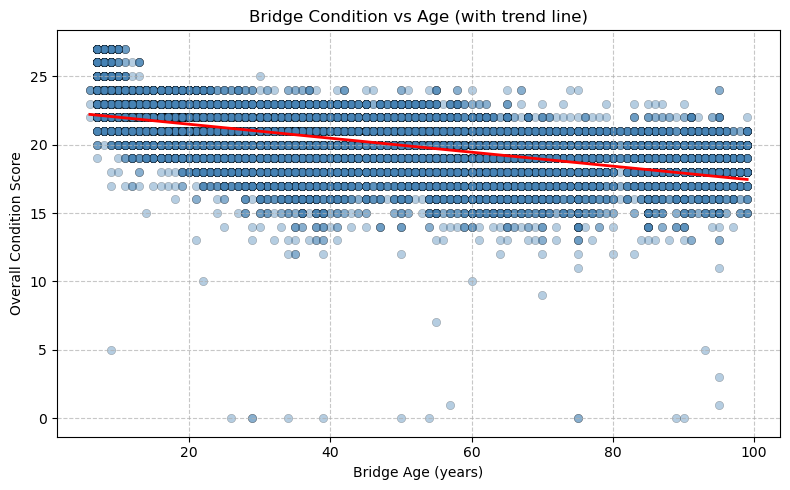

Correlation between Bridge Age and Condition_score: -0.590


In [ ]:
# Scatter plot of Condition_score vs Age
# Define x and y variables
x = bridges_final["Age"]
y = bridges_final["Condition_score"]

# Fit a simple linear regression line
coef = np.polyfit(x, y, 1)          # degree 1 = straight line
poly1d_fn = np.poly1d(coef)

# Create scatter plot with trend line
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.4, color="steelblue", edgecolor="black", linewidth=0.3)
plt.plot(np.sort(x), poly1d_fn(np.sort(x)), color="red", linewidth=2)  # trend line
plt.title("Bridge Condition vs Age (with trend line)")
plt.xlabel("Bridge Age (years)")
plt.ylabel("Overall Condition Score")
plt.grid(axis="both", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Calculate and display correlation coefficient
corr_age = bridges_final[["Age","Condition_score"]].corr().iloc[0,1]
print(f"Correlation between Bridge Age and Condition_score: {corr_age:.3f}")


**Results:** The scatter plot shows a clear negative trend: as bridges become older, their overall condition scores tend to decline. The correlation coefficient of **r = −0.59** indicates a **moderate negative relationship** between bridge age and condition, meaning that older bridges are generally in poorer condition on average. This suggests that age is an important factor in explaining current bridge condition.

This relationship is consistent with expectations for long-term infrastructure performance: condition typically declines over time as bridges remain in service and experience ongoing wear and exposure. The plot also shows some variation around the trend line: a few older bridges maintain relatively high condition scores, while some younger bridges show unexpectedly low scores.This variation suggests that factors other than age, such as traffic levels, design type, or material, also play a role in explaining bridge condition.

Overall, **Age appears to be a strong and key predictor of bridge condition**, supporting its inclusion in the regression model. The downward trend confirms that average condition scores decrease steadily with age, while the scatter indicates that additional predictors will be needed to fully capture the variation in bridge performance.

**Relationship Between Average Daily Traffic and Bridge Condition:**

Traffic loading is another factor that may influence bridge deterioration. This analysis explores how **Average Daily Traffic** relates to the overall **Condition_score**. Since traffic volumes vary greatly between rural and urban bridges, a **logarithmic scale** is used on the x-axis to better visualise patterns across both low and high traffic structures. The scatter plot below shows the relationship between bridge condition and traffic volume, along with the correlation coefficient that quantifies the strength and direction of this relationship.

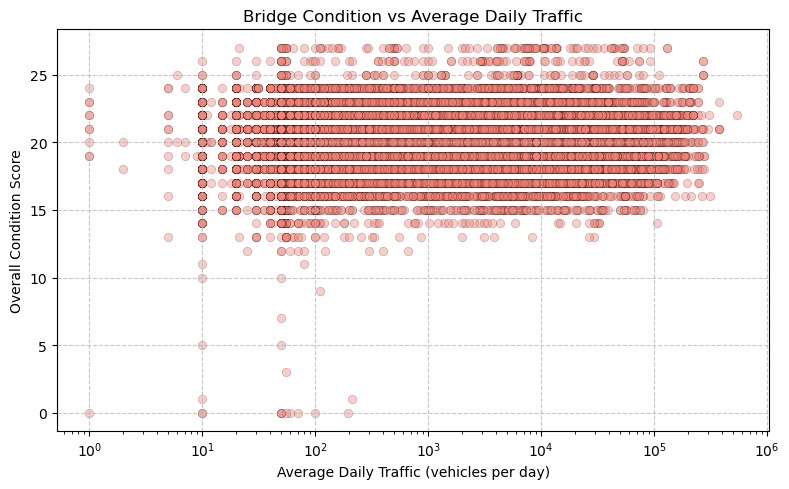

Correlation between AverageDaily and Condition_score: 0.033


In [ ]:
# Scatter plot of Condition_score vs Average Daily Traffic
plt.figure(figsize=(8, 5))
plt.scatter(bridges_final["AverageDaily"], bridges_final["Condition_score"], alpha=0.4, color="salmon", edgecolor="black", linewidth=0.3)
plt.title("Bridge Condition vs Average Daily Traffic")
plt.xlabel("Average Daily Traffic (vehicles per day)")
plt.ylabel("Overall Condition Score")
plt.grid(axis="both", linestyle="--", alpha=0.7)
plt.xscale("log")  ## Use logarithmic scale for better visualization
plt.tight_layout()
plt.show()

# Calculate and display the correlation coefficient
corr_adt = bridges_final[["AverageDaily", "Condition_score"]].corr().iloc[0, 1]
print(f"Correlation between AverageDaily and Condition_score: {corr_adt:.3f}")


**Results:** The scatter plot shows no clear relationship between **Average Daily Traffic** and bridge condition. The correlation coefficient of **r = +0.03** indicates a **negligible linear association**, meaning that traffic volume has little direct effect on the overall condition score.

This result is reasonable when viewed from an engineering perspective. Although heavier traffic increases load cycles and could contribute to fatigue, most bridges are designed with safety factors that accommodate expected volumes. In addition, bridges carrying large numbers of vehicles are typically on major transport routes and receive more frequent inspection or strengthening, which helps maintain their condition.

The wide vertical spread of condition scores at all traffic levels suggests that **traffic is not a dominant predictor** of condition. Instead, differences in **bridge age**, **design**, and **material type** are likely to be stronger explanatory factors. These will be examined in subsequent sections to determine their relative influence on bridge condition.

**Relationship Between Truck Traffic and Bridge Condition:**

The **percentage of heavy trucks** using a bridge is an indicator of structural loading intensity. Because trucks impose greater stresses than cars, a higher proportion of truck traffic could contribute to faster deterioration of bridge components such as expansion joints and bearings. This section examines whether the proportion of truck traffic is associated with differences in overall bridge condition.

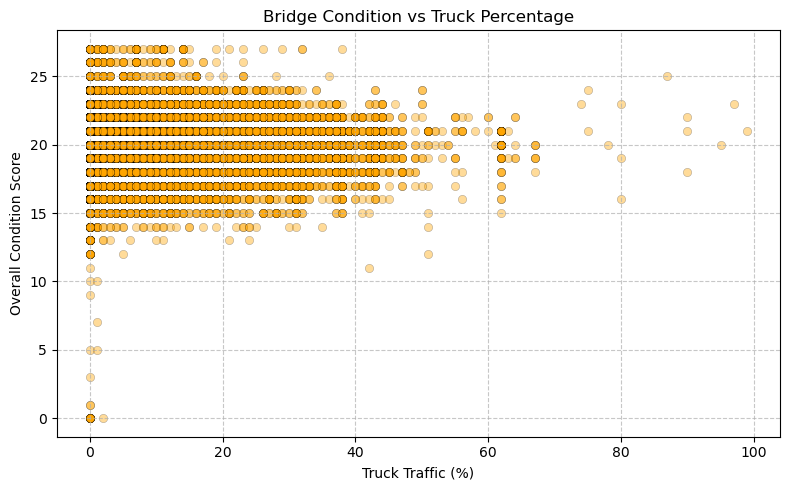

Correlation between Trucks_percent and Condition_score: -0.049


In [ ]:
# Scatter plot of Condition_score vs Trucks_percent
plt.figure(figsize=(8, 5))
plt.scatter(
    bridges_final["Trucks_percent"], bridges_final["Condition_score"], alpha=0.4, color="orange", edgecolor="black", linewidth=0.3
)
plt.title("Bridge Condition vs Truck Percentage")
plt.xlabel("Truck Traffic (%)")
plt.ylabel("Overall Condition Score")
plt.grid(axis="both", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Calculate and display the correlation coefficient
corr_truck = bridges_final[["Trucks_percent", "Condition_score"]].corr().iloc[0, 1]
print(f"Correlation between Trucks_percent and Condition_score: {corr_truck:.3f}")



**Results:** The scatter plot shows no clear relationship between the proportion of truck traffic and bridge condition. The correlation coefficient of **r = −0.05** indicates an extremely weak, almost negligible, negative relationship. In practice, this means that bridges with a higher percentage of truck traffic are neither systematically better nor worse in condition than those with fewer trucks.

This weak relationship is plausible in the context of bridge management. While heavy trucks generate higher stresses and can accelerate fatigue or deck wear, bridges on routes with substantial freight movement are usually inspected more frequently and designed differently to account for these loads. Conversely, bridges on minor routes may experience less truck traffic but might be older or maintained less intensively, offsetting any benefit of lighter use.

Overall, **truck traffic percentage does not appear to be a meaningful predictor** of bridge condition. Its minimal correlation suggests that other factors, particularly **age**, **material**, and **design**, play a much larger role in determining structural condition.

**Relationship Between Bridge Material and Bridge Condition:**

Bridge material plays a critical role in determining durability and resistance to environmental degradation. This section explores how the **construction material** relates to the overall **Condition_score**. The average condition score is calculated for each material category to assess whether certain materials are generally associated with better bridge performance.

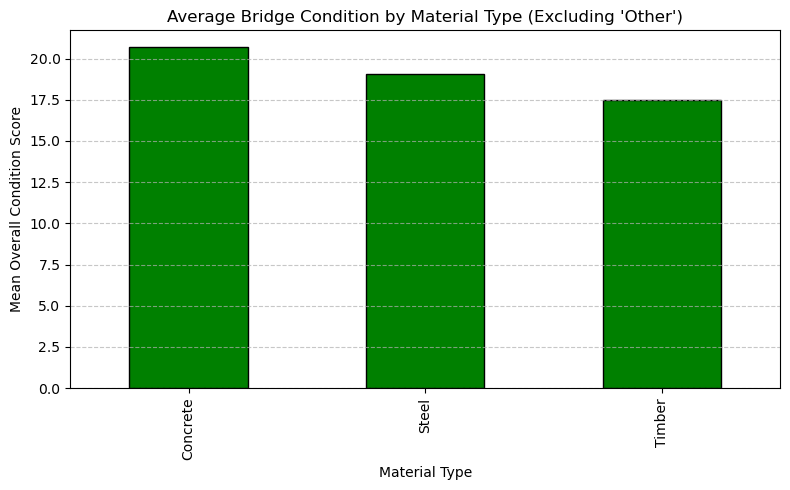

Mean Overall Condition Score by Material Type:
Material_simplified
Concrete    20.68
Steel       19.09
Timber      17.47
Name: Condition_score, dtype: float64


In [ ]:
# Exclude "Other" for clearer visualisation (kept in dataset for regression)
filtered_material = bridges_final[bridges_final["Material_simplified"] != "Other"]

# Calculate mean Condition_score by Material type
mean_condition_by_material = (
    filtered_material.groupby("Material_simplified", observed=True)["Condition_score"]
    .mean()
    .sort_values(ascending=False)
)

# Bar plot of mean Condition_score by Material_simplified
plt.figure(figsize=(8, 5))
mean_condition_by_material.plot(
    kind="bar",
    color="green",
    edgecolor="black"
)
plt.title("Average Bridge Condition by Material Type (Excluding 'Other')")
plt.xlabel("Material Type")
plt.ylabel("Mean Overall Condition Score")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Display mean condition scores by material type
print("Mean Overall Condition Score by Material Type:")
print(mean_condition_by_material.round(2))

**Results:**  The bar chart compares the mean overall condition scores for bridges built from different materials (excluding the small “Other” category for clarity). **Concrete bridges** show the highest average condition (20.7), followed by **steel bridges** (19.0) and **timber bridges** (17.5).

This pattern suggests that material type has a measurable effect on bridge condition. Concrete bridges are generally in better condition on average, while steel and especially timber bridges tend to have lower scores. This likely reflects differences in how these materials perform over time and how frequently structures of each type are maintained or replaced.

Overall, **bridge material appears to influence overall condition**, with concrete performing best on average. These results indicate that material choice is an important factor to consider in explaining long-term variations in bridge condition and will be further examined in the regression analysis.


**Relationship Between Bridge Design and Bridge Condition:**

Bridge design affects how loads are distributed through the structure and how resistant the bridge is to certain types of deterioration. This section explores whether **design type** is associated with differences in average **Condition_score**.

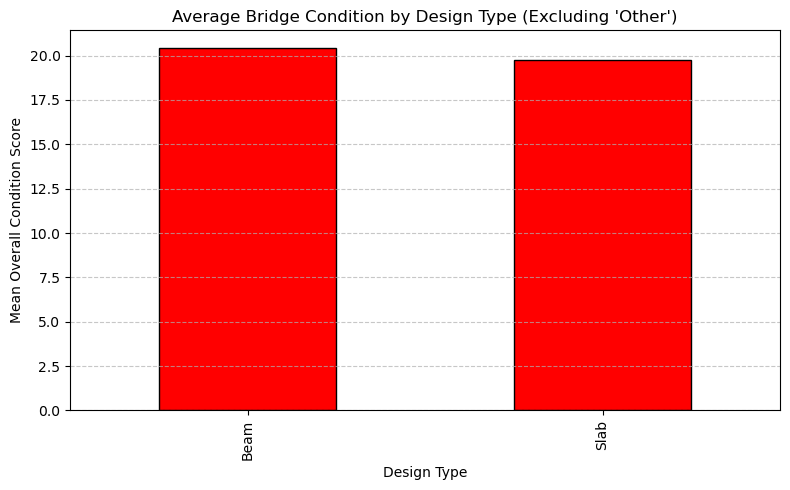

Mean Overall Condition Score by Design Type:
Design_simplified
Beam    20.40
Slab    19.75
Name: Condition_score, dtype: float64


In [ ]:
# Exclude 'Other' for cleaner visualisation (kept in dataset for regression)
filtered_design = bridges_final[bridges_final["Design_simplified"] != "Other"]

# Calculate mean Condition_score by design type
mean_condition_by_design = (
    filtered_design.groupby("Design_simplified", observed=True)["Condition_score"]
    .mean()
    .sort_values(ascending=False)
)

# Bar plot of mean Condition_score by Design_simplified
plt.figure(figsize=(8, 5))
mean_condition_by_design.plot(
    kind="bar",
    color="red",
    edgecolor="black"
)
plt.title("Average Bridge Condition by Design Type (Excluding 'Other')")
plt.xlabel("Design Type")
plt.ylabel("Mean Overall Condition Score")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Display mean condition scores by design type
print("Mean Overall Condition Score by Design Type:")
print(mean_condition_by_design.round(2))

**Results:** The bar chart compares the average overall condition scores for the two main bridge design types in the dataset (excluding the small “Other” category). **Beam bridges** have a slightly higher mean condition score (20.4) than **slab bridges** (19.8), suggesting only a minor difference in overall performance.

This pattern indicates that **design type alone is not a dominant factor** in explaining bridge condition. The small difference may reflect variations in typical span length, construction era, or the materials commonly used with each design. For example, beam bridges are often associated with more recent construction, whereas slab designs are more common among older or smaller structures.

Overall, the results suggest that **bridge design plays a secondary role** compared with other factors such as **material** and **age**. While design may interact with these characteristics, its independent influence on condition appears limited.

**Overall Interpretation - Predictor/Target Relationships:**

The exploratory analysis reveals several clear patterns linking bridge characteristics to their overall structural condition.

* **Age** shows the strongest relationship, with older bridges exhibiting a steady decline in condition — a moderately negative correlation that reflects the cumulative effects of material degradation, corrosion, and fatigue over time.
* In contrast, traffic-related variables such as **average daily traffic** and **truck percentage** show only weak associations with condition. This suggests that design standards, maintenance practices, and load management strategies may effectively mitigate the impact of regular and heavy usage on structural deterioration.
* Among the categorical factors, **material** and **design** each show modest but meaningful differences. Concrete bridges tend to maintain slightly higher condition scores than steel or timber bridges, consistent with concrete’s greater durability and lower maintenance demands. Beam and slab designs display similar average conditions, indicating that **construction era**, **material choice**, and **maintenance frequency** may be stronger differentiators than design form alone.

Overall, **bridge age emerges as the most influential driver of condition**, with material and design contributing secondary effects. These findings provide the foundation for the regression modelling in Section 3, where the combined and relative influence of all predictors will be quantified more precisely.

### Section 2.2: Examine Relationships Between Predictors

This section explores how the five predictor variables (**Age**, **AverageDaily**, **Trucks_percent**, **Material_simplified**, and **Design_simplified**) relate to one another. Understanding these relationships helps identify potential dependencies or grouping effects that may influence the regression analysis.

* **Continuous predictors** (Age, AverageDaily, and Trucks_percent) are compared using correlation matrices and pairwise scatter plots to detect any linear associations or multicollinearity.  
* **Categorical predictors** (Material_simplified and Design_simplified) are examined using cross-tabulations and conditional probability heatmaps to reveal whether certain materials are more commonly associated with particular designs.  
* Finally, **boxplots** compare the distributions of the continuous variables across material and design categories to assess whether traffic levels or bridge ages differ systematically by structural type.

These analyses provide an overview of how the predictor variables interact, highlighting any structural patterns in the dataset that could affect the interpretation of regression coefficients in Section 3.

**Relationships Between Continuous Predictors:**

Before fitting the regression model, it is important to check whether the continuous predictors are correlated with one another. Strong correlations between predictors (multicollinearity) can make it difficult to distinguish their individual effects on bridge condition. Here, **Age**, **AverageDaily**, and **Trucks_percent** are compared using a correlation matrix and pairwise scatter plots.

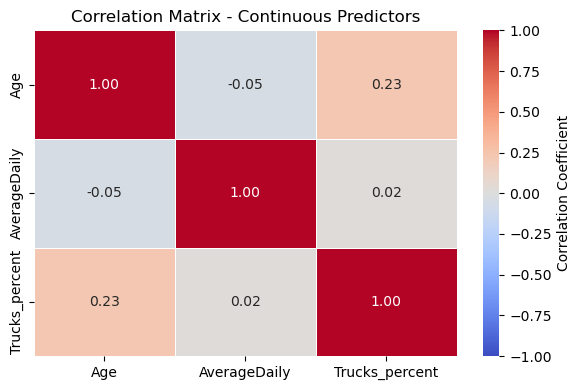

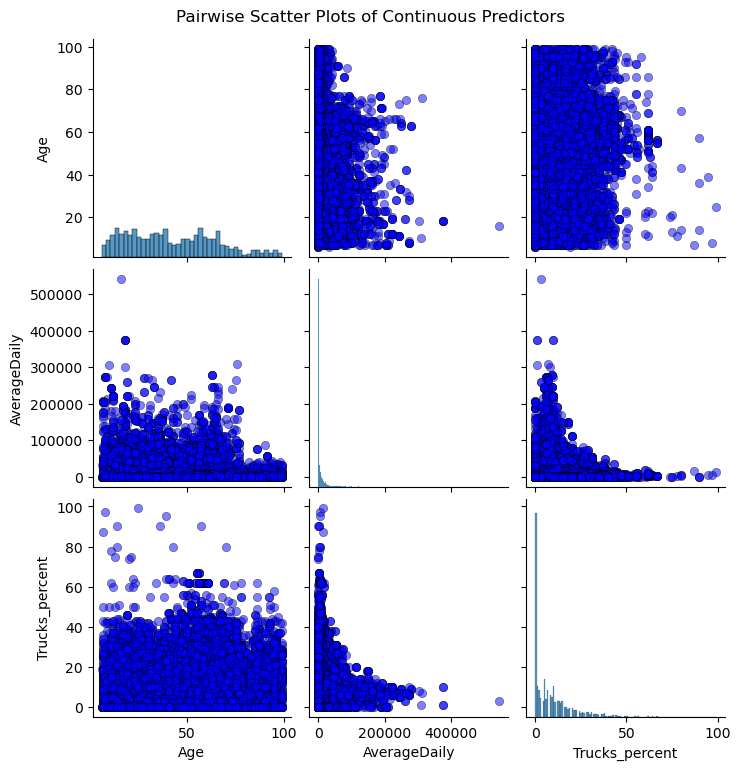

In [ ]:
# Identify continuous variables
cont_vars = ["Age", "AverageDaily", "Trucks_percent"]

# Correlation matrix for continuous variables
corr_matrix = bridges_final[cont_vars].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap= "coolwarm",
    vmin=-1, vmax=1,
    fmt=".2f", linewidths=0.5,
    cbar_kws={"label": "Correlation Coefficient"}
)
plt.title("Correlation Matrix - Continuous Predictors")
plt.tight_layout()
plt.show()

# Scatter Matrix for continuous variables
sns.pairplot(
    bridges_final[cont_vars],
    diag_kind="hist",
    plot_kws={"alpha": 0.5, "color": "blue", "edgecolor": "black"}
)
plt.suptitle("Pairwise Scatter Plots of Continuous Predictors", y=1.02)
plt.show()


**Results:** The correlation heatmap and scatter matrix examine relationships among the three continuous predictors: **Age**, **AverageDaily**, and **Trucks_percent**. All correlations are weak, with the strongest between **Age** and **Trucks_percent** (r = 0.23), suggesting that older bridges may serve routes with a slightly higher proportion of heavy vehicles. **Age** and **AverageDaily** show a small negative relationship (r = −0.05), implying that newer bridges tend to be built on busier routes, while the relationship between **AverageDaily** and **Trucks_percent** is negligible.

The scatter plots reinforce these findings: there are no strong linear patterns or dependencies among the predictors. The distributions of **AverageDaily** and **Trucks_percent** are highly skewed, indicating that most bridges carry moderate traffic volumes while a small subset supports very high-capacity routes.

Overall, the continuous predictors are largely independent, indicating no serious multicollinearity concerns. This independence is advantageous for the regression modelling stage, as it allows the separate effects of **Age**, **traffic volume**, and **truck proportion** to be estimated more reliably.

**Relationships Between Categorical Predictors:**

Bridge **material** and **design** are not independent decisions: certain design types are more compatible with particular materials. Understanding how these categories overlap helps identify potential grouping effects that may influence the regression results. Here, a cross-tabulation shows how many bridges of each material correspond to each design, followed by a row-normalised version showing conditional probabilities of design type within each material category.

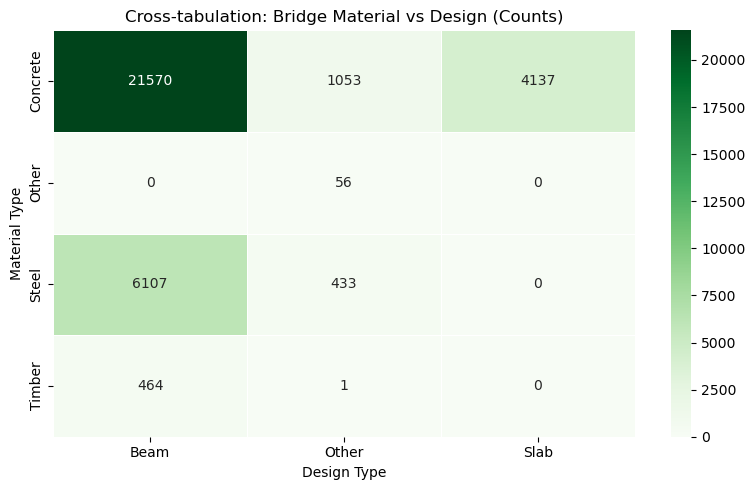

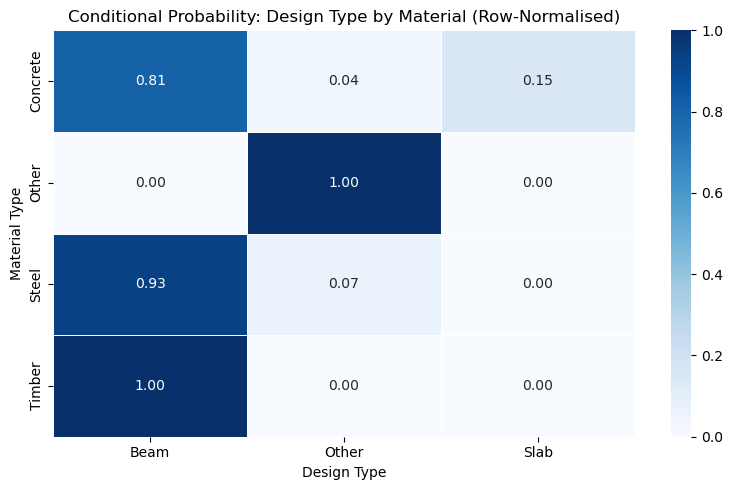

In [ ]:
# Cross-tabulation of Material and Design
cross_tab = pd.crosstab(
    bridges_final["Material_simplified"],
    bridges_final["Design_simplified"]
)
# Row-normalised conditional probabilities
cond_prob = pd.crosstab(
    bridges_final["Material_simplified"],
    bridges_final["Design_simplified"],
    normalize="index"
)

# Heatmap of raw counts
plt.figure(figsize=(8, 5))
sns.heatmap(cross_tab, cmap="Greens", annot=True, fmt="d", linewidths=0.5)
plt.title("Cross-tabulation: Bridge Material vs Design (Counts)")
plt.xlabel("Design Type")
plt.ylabel("Material Type")
plt.tight_layout()
plt.show()

# Heatmap of conditional probabilities
plt.figure(figsize=(8, 5))
sns.heatmap(cond_prob, cmap="Blues", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Conditional Probability: Design Type by Material (Row-Normalised)")
plt.xlabel("Design Type")
plt.ylabel("Material Type")
plt.tight_layout()
plt.show()


**Results:**  The cross-tabulations and heatmaps show clear structural relationships between **bridge material** and **design type**. Most bridges in the dataset are **concrete** or **steel**, and the vast majority of these follow **beam designs**. Specifically, about **81% of concrete bridges** are beams, with a smaller proportion (**15%**) built as slabs. Among **steel** bridges, the dominance of the beam design is even stronger (around **93%**), while **timber** bridges are almost exclusively beam-type structures.

These patterns indicate that bridge **material and design are not independent**. Concrete is used in both beam and slab configurations, while steel and timber are mainly associated with beam designs. This reflects common construction choices within the dataset — for example, concrete is applied across a wider range of bridge types, whereas steel and timber are used more narrowly.

Overall, material and design are **related but not redundant**. Material choice appears to influence the likelihood of a particular design being used, but each variable still captures distinct information about bridge characteristics. This interdependence is expected and does not present any issues for regression modelling, as both features describe different aspects of bridge construction and performance.

### 2.3: Distributions of Continuous Variables Across Categorical Groups

This section investigates how key **continuous predictors vary across categorical bridge characteristics**, providing insight into the structural and operational factors that may influence bridge condition.

* The **distributions of Age, AverageDaily, and Trucks_percent (continuous variables) are compared across categories of Material_simplified and Design_simplified** using boxplots to highlight differences in central tendency and spread.
* These visualisations help identify whether certain materials or design types are associated with older bridges, higher traffic volumes, or greater proportions of truck traffic.
* A layered scatter plot combining Age, Condition_score, and Material_simplified further illustrates how condition deteriorates with age across different material types.

Together, these analyses provide a detailed understanding of how continuous and categorical predictors interact, offering important context for interpreting the results of the subsequent regression modelling.

**Distribution of Bridge Age by Material Type:**

As discovered already, bridge age is a key indicator of potential deterioration. Different materials have been adopted in different construction periods, meaning that the **age distribution varies by material type**.  

This section examines whether certain materials such as, concrete, steel, or timber are generally associated with older or newer bridges. A boxplot is used to compare the **distribution of bridge ages** across materials, highlighting differences in median, variability, and outliers. Understanding these patterns helps to interpret how material choice relates to construction era and, consequently, to the condition of the bridge stock.

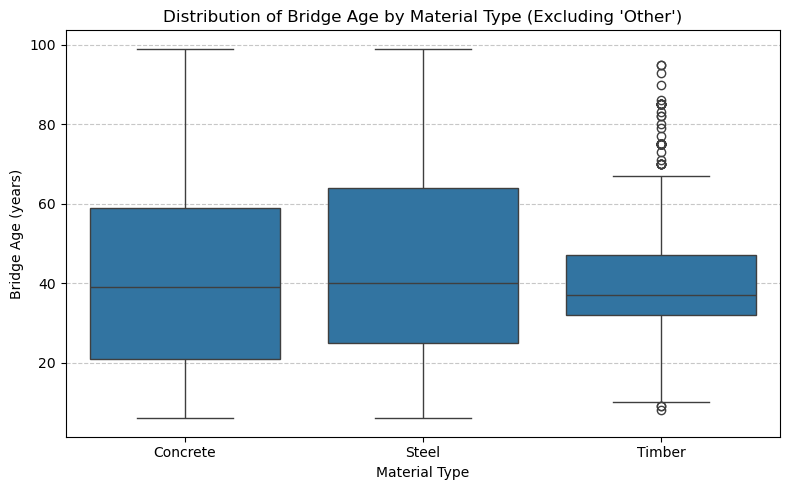

In [ ]:
# Exclude 'Other' for clearer visualisation
filtered_material = (
    bridges_final[bridges_final["Material_simplified"] != "Other"]
    .copy()
)
filtered_material["Material_simplified"] = (
    filtered_material["Material_simplified"].cat.remove_unused_categories()
)

# Box plot of Age by Material type
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="Material_simplified",
    y="Age",
    data=filtered_material
)

plt.title("Distribution of Bridge Age by Material Type (Excluding 'Other')")
plt.xlabel("Material Type")
plt.ylabel("Bridge Age (years)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

**Results:** The boxplot shows that bridge age varies across materials. **Concrete bridges** tend to be moderately aged with a relatively narrow spread, reflecting widespread mid- to late-century construction and gradual replacement over time. **Steel bridges** display the widest age range, including many older mid-century structures that remain in service today as well as some newer installations. **Timber bridges**, although generally fewer, have a slightly lower median age but show a concentration of outliers. These represent a few very old structures that have remained in use for many decades despite limited durability. The category **“Other”** was excluded from this visualisation to focus on the main material types (Concrete, Steel, and Timber). It represents a small and heterogeneous group of bridges that do not meaningfully contribute to the comparison.

These patterns align with expectations from bridge engineering practice. Timber is mainly used for short-span or rural bridges, often replaced or reconstructed periodically. Steel bridges, while strong and versatile, require ongoing maintenance to mitigate corrosion, whereas modern concrete designs tend to offer better longevity and lower upkeep costs.  

Overall, the plot shows that **material choice is closely linked to construction era and maintenance patterns** — a factor that helps explain differences in bridge condition observed in the next stage of the analysis.

**Distribution of Average Daily Traffic by Bridge Design:**

Traffic loading is a key operational characteristic influencing bridge wear and maintenance needs. This section examines how **average daily traffic** differs between the two main bridge design types — **beam** and **slab**. Because traffic volumes vary widely between small rural crossings and large highway structures, a **logarithmic scale** is used to make differences in magnitude clearer. This comparison helps to understand whether particular designs are associated with heavier use and, therefore, greater exposure to loading stress.


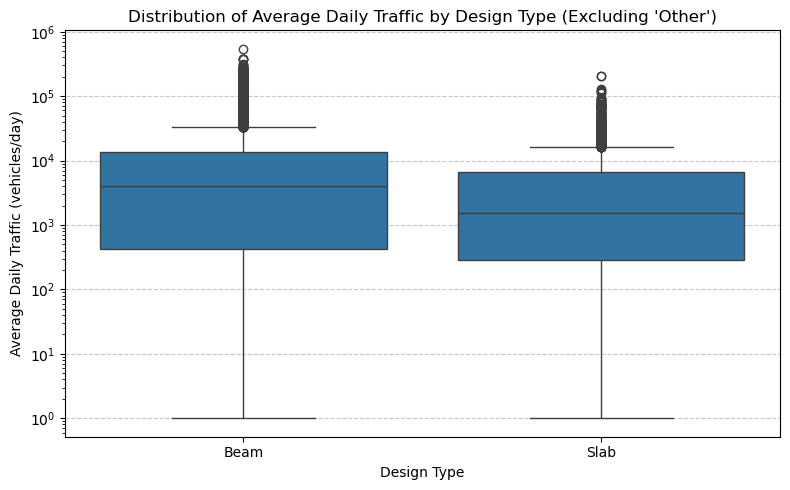

In [ ]:
# Exclude 'Other' for clearer visualisation
filtered_design = (
    bridges_final[bridges_final["Design_simplified"] != "Other"]
    .copy()
)
filtered_design["Design_simplified"] = (
    filtered_design["Design_simplified"].cat.remove_unused_categories()
)

# Box plot of Average Daily Traffic by Design type
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="Design_simplified",
    y="AverageDaily",
    data=filtered_design
)

plt.yscale("log")  # log scale to handle wide traffic range
plt.title("Distribution of Average Daily Traffic by Design Type (Excluding 'Other')")
plt.xlabel("Design Type")
plt.ylabel("Average Daily Traffic (vehicles/day)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()



**Results:** **Beam bridges** show a slightly higher median average daily traffic and a wider spread than **slab bridges**, indicating that beam designs are more commonly found on major routes that carry larger and more variable traffic volumes. **Slab bridges**, by contrast, generally serve shorter spans and local or secondary roads with lower traffic demand.

These patterns are consistent with engineering expectations. Beam designs provide greater span capacity and are therefore suited to main corridors where higher loads and traffic intensity occur, while slab bridges are typically used for short spans or minor road networks.

Overall, the plot highlights that **bridge design type is related to functional role within the transport network**: beam bridges tend to serve high‐capacity routes, whereas slab bridges are associated with lighter, local traffic.

**Distribution of Truck Percentage by Material Type:**

Heavy-vehicle traffic contributes disproportionately to bridge fatigue and deck wear. This section compares the **percentage of truck traffic** across different bridge materials to explore whether certain materials are more frequently used on freight corridors. Boxplots are used to visualise differences in distribution, highlighting how exposure to truck loading may vary with material type.

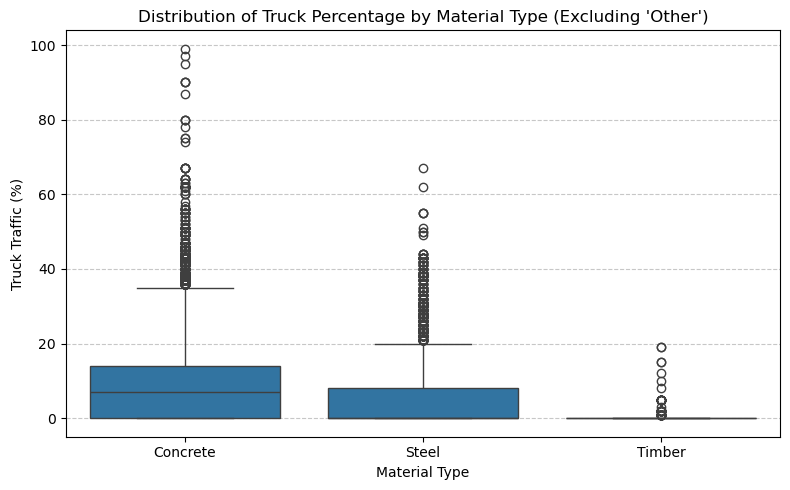

In [ ]:
# Exclude 'Other' for clearer visualisation
filtered_material = (
    bridges_final[bridges_final["Material_simplified"] != "Other"]
    .copy()
)
filtered_material["Material_simplified"] = (
    filtered_material["Material_simplified"].cat.remove_unused_categories()
)

# Box plot of Truck Percentage by Material type
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="Material_simplified",
    y="Trucks_percent",
    data=filtered_material
)

plt.title("Distribution of Truck Percentage by Material Type (Excluding 'Other')")
plt.xlabel("Material Type")
plt.ylabel("Truck Traffic (%)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


**Results:** The boxplot shows that the proportion of heavy vehicles varies across bridge materials. **Concrete bridges** exhibit the widest range of truck percentages, with several outliers representing bridges on high-capacity freight corridors. **Steel bridges** have a lower median truck proportion and a narrower spread, indicating moderate exposure to heavy-vehicle traffic. **Timber bridges** generally carry minimal truck traffic, reflecting their typical location on lightly trafficked rural routes. The category **“Other”** was excluded from this visualisation to focus on the main material types (Concrete, Steel, and Timber).  

These results align with practical expectations. Concrete bridges, which dominate the primary road network, accommodate a broad spectrum of traffic intensities — from light mixed-use routes to heavy freight corridors. Steel bridges, often older, are still found on important but less heavily trafficked routes. Timber bridges tend to serve local or low-volume crossings where large vehicles are rare.

Overall, the plot suggests that **material type indirectly reflects bridge usage and network role**, with concrete structures exposed to the highest levels of truck traffic.

**Layered View of Age and Condition by Material:**

This layered scatter plot integrates key relationships between **bridge age**, **material**, and **overall condition**. Colouring the points by material type allows patterns of deterioration to be compared across materials, illustrating how age and construction type jointly influence condition. This visual provides a holistic summary of the dataset before regression analysis, highlighting whether any material consistently maintains higher condition scores at similar ages.

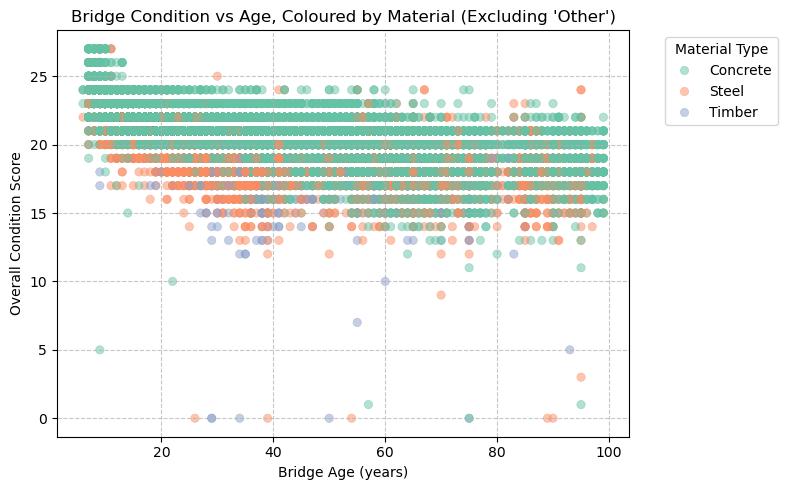

In [ ]:
# Exclude 'Other' for clearer visualisation
filtered_bridges = (
    bridges_final[bridges_final["Material_simplified"] != "Other"]
    .copy()
)
# Remove unused category if variable is categorical
filtered_bridges["Material_simplified"] = (
    filtered_bridges["Material_simplified"].cat.remove_unused_categories()
    )

# Scatter plot of Condition vs Age, coloured by Material
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x="Age",
    y="Condition_score",
    hue="Material_simplified",
    data=filtered_bridges,
    alpha=0.5,
    palette="Set2",
    edgecolor=None
)
plt.title("Bridge Condition vs Age, Coloured by Material (Excluding 'Other')")
plt.xlabel("Bridge Age (years)")
plt.ylabel("Overall Condition Score")
plt.grid(axis="both", linestyle="--", alpha=0.7)
plt.legend(title="Material Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



**Results:** The scatter plot shows a clear downward trend in condition score as bridge age increases, confirming that older bridges generally have lower condition ratings. Distinct patterns appear for each material:  

* **Concrete bridges** (green) maintain relatively high condition scores across a broad age range, suggesting slower deterioration and greater durability.  
* **Steel bridges** (orange) show a wider spread and a more visible decline in condition with age, consistent with the effects of corrosion and fatigue in long-serving steel structures.  
* **Timber bridges** (purple) cluster mainly at lower condition scores, even at moderate ages, reflecting their limited durability and shorter service life.  

Overall, these patterns confirm that while **age is the dominant predictor of bridge condition**, **material type significantly affects the rate of deterioration**. Concrete bridges tend to remain in good condition for longer, whereas steel and timber structures show faster declines. This layered visual reinforces the insights from earlier analyses and provides clear justification for including both **Age** and **Material** as key predictors in the regression model.


### 2.4: Preliminary Conclusions

The exploratory analysis provides a detailed view of how structural, material, and operational characteristics relate to overall bridge condition.

* Across all visualisations, **Age** consistently emerges as the most influential factor. The relationship between age and condition is moderately strong and negative, showing that as bridges become older, their condition scores decline almost uniformly. This pattern indicates a steady process of deterioration over time, with older bridges rarely achieving high condition ratings. Age therefore appears to be a primary indicator of asset degradation within the network.
* **Material type** also shows a meaningful influence. Concrete bridges display the highest average condition scores and the slowest apparent decline with age, while steel bridges show greater variation and timber bridges record the lowest scores. These differences suggest that bridge materials differ in their long-term performance and maintenance demands, with concrete generally associated with better overall condition.
* **Design type** has a smaller but noticeable effect. Beam bridges record slightly higher mean condition scores than slab bridges, which may relate to differences in span length, construction period, or the routes on which they are used. The small difference indicates that design contributes to condition variation but is not a dominant factor on its own.
* The **traffic-related predictors**, Average Daily Traffic and Truck Percentage, show very weak linear associations with condition. This suggests that while traffic loading contributes to bridge use and wear, its effects may be managed effectively through design standards and maintenance practices. Bridges on higher-volume routes appear to perform comparably to those on lighter networks once other factors are accounted for.

Examining relationships among the predictors revealed no major issues with multicollinearity. Age, traffic volume, and truck percentage are largely independent, while material and design show logical but non-redundant overlap (for example, most concrete bridges are slabs or beams). This supports the inclusion of all five predictors in the regression model.

Overall, the exploratory analysis indicates that **bridge age and material** are the main drivers of condition, with design exerting a smaller influence and traffic intensity playing a limited role. These findings provide both practical and statistical justification for including these variables in the regression model. The next section will formally quantify these effects and evaluate how effectively the combined predictors explain variation in bridge condition across the network.

## Section 3 - Regression Modelling

**Aims and Outline:**

The aim of this section is to build and evaluate a linear regression model that predicts the overall bridge condition score (Condition_score) using five key predictors: Age, AverageDaily, Trucks_percent, Material, and Design.

The regression analysis quantifies how each factor influences bridge condition while controlling for the effects of the others, allowing direct comparison of their relative importance. Model performance is assessed using appropriate statistical metrics, and diagnostic checks are conducted to confirm that the assumptions of linear regression are satisfied.

**Specifically, this section aims to:**

* Fit a multiple linear regression model to the complete dataset using the five specified predictor variables.
* Evaluate model performance using R2 (coefficient of determination) and RMSE (Root Mean Squared Error), with clear explanations of their meaning and practical interpretation.
* Examine the residuals to assess normality, bias, and constant variance, ensuring that the model is statistically valid and unbiased.
* Interpret the regression coefficients to determine the direction and strength of each predictor’s influence and relate these findings to the patterns observed during the exploratory analysis.
* Draw final, numerically supported conclusions addressing the Texas Department of Transportation’s key questions:
    1. Which of the proposed predictors most strongly influence bridge condition?
    2. How well do the predictors collectively explain and predict bridge condition?
* Provide concise recommendations for further analysis, such as incorporating additional explanatory variables, testing interaction effects, or exploring non-linear model forms.

This section forms the analytical core of the coursework, translating the relationships identified in the exploratory analysis into a formal statistical model that quantifies the key drivers of bridge condition across the Texas dataset.

### 3.1: Prepare Data and Fit the Regression Model

This section prepares the dataset and fits a **multiple linear regression model** to quantify how the selected predictors (**Age**, **AverageDaily**, **Trucks_percent**, **Material_simplified**, and **Design_simplified**) explain variation in overall bridge condition (**Condition_score**). Categorical variables are converted into dummy variables using reference encoding to allow their inclusion in the model. The fitted model provides the basis for evaluating predictive performance and the relative importance of each predictor in the following sections.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# List of predictors
predictors = ["Age", "AverageDaily", "Trucks_percent",
              "Material_simplified", "Design_simplified"]

# Create dummy variables for categorical predictors (reference encoding)
X = pd.get_dummies(bridges_final[predictors],
                   drop_first=True).astype(float)

# Target variable (overall bridge condition)
y = bridges_final["Condition_score"]

# Fit the multiple linear regression model on the full dataset

model = LinearRegression()
model.fit(X, y)

# Generate fitted (predicted) values
y_pred = model.predict(X)

# Confirm structure
print("Predictor matrix shape:", X.shape)
X.head()

Predictor matrix shape: (33821, 8)


,Age,AverageDaily,Trucks_percent,Material_simplified_Other,Material_simplified_Steel,Material_simplified_Timber,Design_simplified_Other,Design_simplified_Slab
Structure_id,,,,,,,,
000021521-00101,20.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
000021521-00181,20.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
000021521-TMP20,13.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0
000021525-00012,75.0,80.0,0.0,0.0,0.0,1.0,0.0,0.0
000021580-00092,21.0,150.0,4.0,0.0,0.0,0.0,0.0,0.0


**Results:** The regression model was fitted successfully on 33,821 bridges, using eight predictor variables derived from the five main characteristics identified in Section 2. Dummy variables were automatically created for the categorical predictors (**Material_simplified** and **Design_simplified**), using reference encoding so that **Concrete and Beam serve as baseline categories**. This allows each coefficient to be interpreted relative to these common bridge types.  

The model is now ready for evaluation through performance metrics and diagnostic analysis, which will assess how effectively the predictors explain variation in bridge condition.

### 3.2: Evaluate Model Performance

Two standard but complementary metrics are used to assess the performance of the regression model:

* **R2 (R-squared) (Coefficient of Determination)** – measures how much of the variation in bridge condition scores is explained by the model’s predictors.
* **RMSE (Root Mean Squared Error)** – quantifies the model’s average prediction error in the same units as the condition score.

Together, these metrics provide a balanced view of model quality: R2 summarises explanatory power, while RMSE expresses predictive accuracy in practical, interpretable terms.


In [ ]:
# Coefficient of determination (R2)
R2 = model.score(X, y)

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"R2:  {R2:.3f}")
print(f"RMSE: {rmse:.3f}")

R2:  0.454
RMSE: 1.468


**Results:**  The regression model's **R2** is **0.454**, which indicates that the five variables in the model account for around **45% of the variance in bridge condition**.  For a high-level engineering dataset, where conditions are impacted by several other variables including construction quality, environmental exposure, and maintenance methods that are not included in the model, this indicates a **moderate level of explanatory power**.

The model’s **RMSE of 1.47** indicates that predictions differ from actual condition scores by roughly **±1.5 points** on average. Given that condition scores range from about 0 to 27, this is a **small average prediction error**, showing that the model’s fitted values are generally close to observed conditions.

Overall, the model demonstrates **reasonably accurate and beneficial predictive performance**, capturing key influences such as bridge age and material while maintaining acceptable accuracy to support and guide the Texas Department of Transportation's asset management decisions. This provides a solid basis for further diagnostic checks and interpretation of predictor influence in the following sections.

### 3.3: Residual Diagnostics

The main purpose of this section is to evaluate the performance and reliability of the fitted regression model by comparing the predicted bridge condition scores to the actual observed values. If the regression fits well, the points should lie close to the diagonal reference line, indicating accurate predictions. The distribution of the residuals (prediction errors) is also examined to confirm that they are approximately normally distributed and centred around zero, supporting the validity of the linear regression assumptions.

In [ ]:
# Print residuals summary and round to 3 decimal places for clarity
residuals = y - y_pred
print(f"Residual Summary (rounded):")
print(residuals.describe().round(3))

Residual Summary (rounded):
count    33821.000
mean         0.000
std          1.468
min        -20.074
25%         -0.839
50%          0.061
75%          0.904
max          7.373
Name: Condition_score, dtype: float64


**Results:** The residual summary shows that the regression errors are well-centred around zero (**mean = 0**), indicating that the model does not systematically over- or under-predict bridge condition.  

The **standard deviation of 1.47** is consistent with the previously reported RMSE (1.47), confirming that the overall spread of prediction errors matches the model’s average error magnitude.

Residual values range from **–20.1 to +7.4**, which is expected given that a few bridges have unusually low observed condition scores that the model underestimates. However, the middle 50 % of residuals (interquartile range –0.84 to +0.90) are tightly clustered around zero, suggesting that most predictions are accurate within roughly **±1 point** of the actual condition score.

Overall, the residual distribution appears approximately symmetric and centred, implying that the linear model is unbiased and that the errors are reasonably well behaved. These numerical diagnostics provide initial evidence that the regression assumptions are satisfied, which is explored further through the residual plots that follow.

**Actual vs Predicted Bridge Condition:**

This plot compares the **predicted condition scores** generated by the regression model with the **actual observed scores** from the dataset. A perfect model would produce points lying exactly along the diagonal reference line (where predicted equals actual). The closer the points are to this line, the more accurately the model predicts bridge condition. Deviations from the line indicate prediction errors, helping to visually assess how well the regression captures variation across the full range of condition scores.

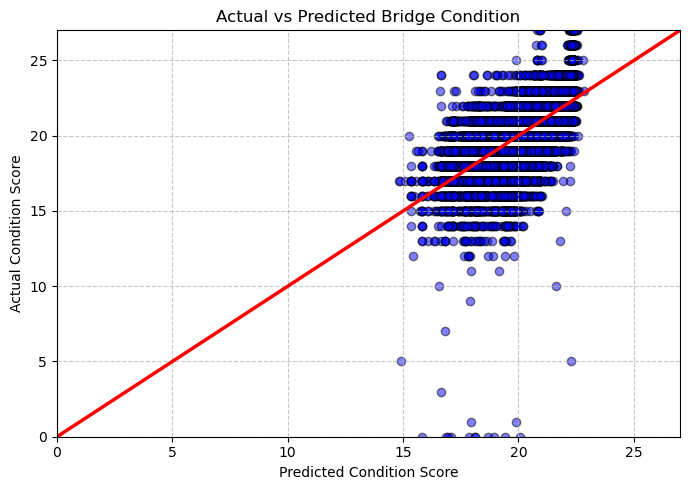

In [ ]:
# Scatter plot of Actual vs Predicted Condition Scores
plt.figure(figsize=(7,5))
plt.scatter(y_pred, y, alpha=0.5, color="blue", edgecolor="black")
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red", linewidth=2.5)
plt.xlim(y.min(), y.max())
plt.ylim(y.min(), y.max())
plt.title("Actual vs Predicted Bridge Condition")
plt.xlabel("Predicted Condition Score")
plt.ylabel("Actual Condition Score")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

**Results:** The model often predicts conditions correctly, as shown by the majority of points being around the 45 degree reference line.  Normal random error is shown by some vertical dispersion around the line, but the model may be underestimating the state of the best-performing bridges due to the minor compression of points near the top of the range.

The assumption of a **linear relationship between the predictors and condition score** is supported by the residuals' lack of a discernible curve or pattern.  All things considered, the graphic demonstrates that the regression model fits the data rather well, capturing the primary variance in bridge condition without exhibiting any systematic bias.

**Distribution of Residuals (Prediction Errors):**

To check whether the regression assumptions are satisfied, the distribution of the residuals (prediction errors) is plotted. If the model fits well, the residuals should be **centred around zero** and approximately **normally distributed**. This ensures that the linear regression provides unbiased predictions and that its error structure is suitable for interpretation.

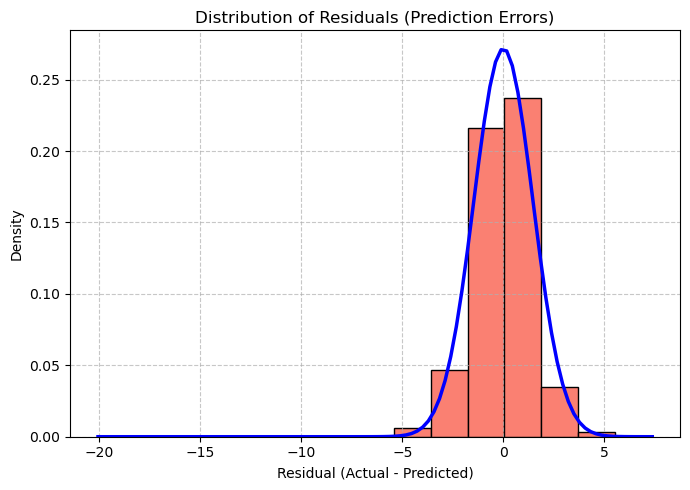

In [ ]:
from scipy.stats import norm

# Compute residuals
residuals = y - y_pred

# Histogram of residuals with overlaid normal distribution curve
plt.figure(figsize=(7,5))
plt.hist(residuals, bins=15, color="salmon", edgecolor="black", density=True)

x_vals = np.linspace(residuals.min(), residuals.max(), 100)
plt.plot(x_vals, norm.pdf(x_vals, residuals.mean(), residuals.std()), color="blue", linewidth=2.5)

plt.title("Distribution of Residuals (Prediction Errors)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Density")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()



**Results:** The residuals are roughly centred around zero, according to the histogram, indicating that the model does not consistently overestimate or underestimate bridge condition.  With the exception of a few bridges whose actual condition ratings are lower than anticipated, the distribution's form is rather similar to a normal curve.  This trend is common in infrastructure datasets, where small asymmetry is introduced by severe degradation events.

The linear regression model's validity for understanding how the predictors affect bridge condition is supported by the residuals' overall compliance with the requirements of **normality and unbiased errors**.

**Residuals vs Predicted Bridge Condition:**

Th plot below compares the **residuals (prediction errors)** with the **predicted bridge condition scores**. If the regression assumptions hold, the residuals should be evenly scattered around the horizontal zero line with no clear trend or pattern. Any systematic curve, slope, or widening spread would suggest non-linearity or heteroscedasticity (unequal variance) that could limit model reliability.

While the *Actual vs Predicted* scatter plot above demonstrates how closely the model’s predictions match the observed bridge condition scores, the *Residuals vs Predicted* plot provides a diagnostic check of the model’s reliability. By plotting residuals rather than raw condition scores, this view highlights whether the errors are randomly distributed — a key assumption of linear regression. A random, even spread around zero indicates that the linear model is appropriate and that prediction errors are unbiased across the range of predicted condition values.

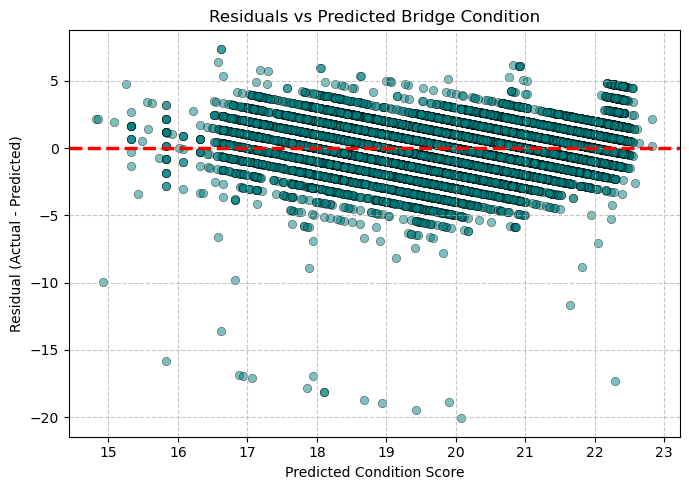

In [ ]:
# Scatter plot of Residuals vs Predicted Condition Scores
residuals = y - y_pred

plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals, alpha=0.5, color="teal", edgecolor="black", linewidth=0.5)
plt.axhline(0, color="red", linestyle="--", linewidth=2.5)
plt.title("Residuals vs Predicted Bridge Condition")
plt.xlabel("Predicted Condition Score")
plt.ylabel("Residual (Actual - Predicted)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

**Results:** The residuals are distributed fairly evenly around the zero line, with no strong curvature or widening spread. This indicates that the **assumptions of linearity and constant variance** are broadly satisfied. The slight downward tilt of the residual cloud suggests that the model tends to slightly underpredict bridges with higher predicted condition scores, but this effect is small and not concerning for overall model validity.  

Bridges in lower than anticipated condition are represented by a few big negative residuals, which are probably outliers brought on by local environmental conditions or location specific degradation.  All things considered, the pattern demonstrates that the linear model is adequate and that the predictors accurately depict the primary structural patterns in the data without adding systematic bias.

**Q–Q Plot of Regression Residuals:**

A **Q–Q (Quantile–Quantile) plot** is used to further support whether the residuals follow a normal distribution, which is a key assumption of linear regression. If the residuals are normally distributed, the plotted points should fall approximately along the reference (red) line. Deviations from this line, especially at the tails, indicate departures from normality that may affect statistical inference but are often acceptable in large engineering datasets.

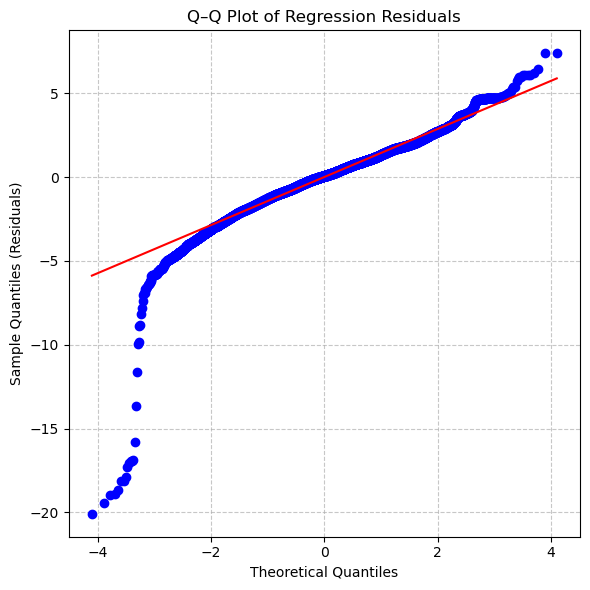

In [ ]:
import scipy.stats as stats

# Q–Q Plot of Residuals to assess normality
plt.figure(figsize=(6,6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q–Q Plot of Regression Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles (Residuals)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

**Results:** The Q–Q plot shows that the central portion of the residuals aligns closely with the reference line, indicating that the majority of errors are approximately normally distributed. However, the tails of the distribution deviate slightly, with a few large negative and positive residuals corresponding to bridges whose conditions differ more sharply from model predictions.

This mild departure from normality is not uncommon in infrastructure data and is typically caused by a small number of extreme cases (for example, bridges in unusually poor or unexpectedly good condition). As the deviations are limited to the extremes and the overall pattern is linear through the centre, the assumption of normal residuals can be considered **reasonably satisfied** for interpretive and predictive purposes.

**Summary:**

The diagnostic checks collectively indicate that the regression model provides a reliable and statistically valid representation of bridge condition.

* The **Actual vs Predicted** plot showed that most predictions lie close to the diagonal reference line, confirming that the model predicts bridge condition scores accurately overall.
* The **residual histogram** and **Q–Q plot** both demonstrated that the residuals are approximately normally distributed and centred around zero, indicating that the model is unbiased and that random errors follow a predictable pattern. Although minor departures from normality appear at the tails, these are attributed to a small number of bridges in unusually poor or unexpectedly good condition and are not sufficient to undermine model validity.
* The **Residuals vs Predicted** plot confirmed that the residuals are evenly scattered across the range of fitted values, with no clear trend or funnel shape. This suggests that the assumptions of **linearity** and **constant variance (homoscedasticity)** are satisfied, meaning the model’s error variance remains stable across different predicted condition levels.  

Overall, the diagnostics provide strong evidence that the **multiple linear regression model is appropriate for explaining variation in bridge condition**, with no major violations of regression assumptions. The model can therefore be considered statistically robust and suitable for interpreting the influence of each predictor in the following section.

### 3.4: Interpreting Regression Coefficients

This section interprets the estimated regression coefficients to understand how each predictor influences overall bridge condition. The coefficients are presented in their original units (not normalised) so that each value reflects the real-world change in bridge condition associated with a one-unit change in the predictor. The table is ordered by the absolute size of the coefficients, highlighting the variables with the greatest overall influence.  

Continuous variables (Age, AverageDaily, Trucks_percent) are measured in their original units, while categorical predictors (Material and Design) are represented by dummy variables compared to reference groups (*Concrete/Beam*). By examining the magnitude and direction of these coefficients, we can identify which factors have the strongest effects and whether the results are consistent with engineering expectations.

Regression Coefficients (sorted by magnitude):



,Variable,Coefficient,|Coefficient|
0,Intercept,2.273573e+01,2.273573e+01
6,Material_simplified_Timber,-3.184328e+00,3.184328e+00
5,Material_simplified_Steel,-1.368798e+00,1.368798e+00
4,Material_simplified_Other,1.350969e-01,1.350969e-01
8,Design_simplified_Slab,-7.569064e-02,7.569064e-02
1,Age,-4.970895e-02,4.970895e-02
7,Design_simplified_Other,-1.722886e-02,1.722886e-02
3,Trucks_percent,5.055837e-03,5.055837e-03
2,AverageDaily,-7.722058e-07,7.722058e-07


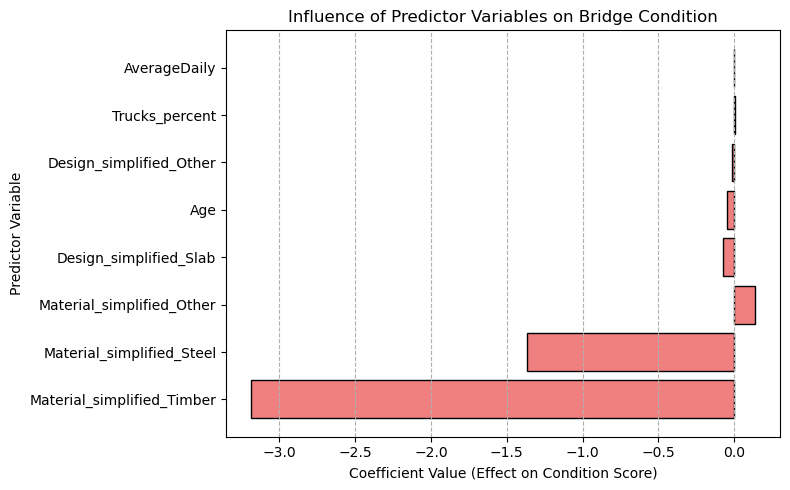

In [ ]:
# Combine intercept and coefficients into a single DataFrame
coef_table = pd.DataFrame({
    "Variable": ["Intercept"] + list(X.columns),
    "Coefficient": [model.intercept_] + list(model.coef_)
})

# Calculate absolute values for easier comparison
coef_table["|Coefficient|"] = np.abs(coef_table["Coefficient"])

# Sort by magnitude (most influential first)
coef_table = coef_table.sort_values(by="|Coefficient|", ascending=False)

print("Regression Coefficients (sorted by magnitude):\n")
display(coef_table)

# Visualise coefficients excluding the intercept
coef_table_plot = coef_table[coef_table["Variable"] != "Intercept"]

plt.figure(figsize=(8, 5))
plt.barh(coef_table_plot["Variable"], coef_table_plot["Coefficient"],
         color="lightcoral", edgecolor="black")
plt.title("Influence of Predictor Variables on Bridge Condition")
plt.xlabel("Coefficient Value (Effect on Condition Score)")
plt.ylabel("Predictor Variable")
plt.grid(axis="x", linestyle="--")
plt.tight_layout()
plt.show()


**Results:**  The regression coefficients quantify how each predictor affects the overall bridge condition score while controlling for the others.

* **Age (−0.05)** — The small but negative coefficient confirms that older bridges generally have lower condition scores, consistent with gradual structural ageing and material fatigue. The magnitude indicates a modest yearly decline in condition, which accumulates over time.
* **Material type** has the strongest influence among the predictors:  
    * **Timber (−3.18)** bridges show markedly lower condition scores than concrete, reflecting the lower long-term durability and greater maintenance needs of timber structures.  
    * **Steel (−1.37)** bridges also perform worse than concrete, though to a lesser extent, consistent with corrosion effects mitigated by maintenance.  
    * **Other materials (+0.14)** show only a minor positive deviation, likely reflecting small design variations or data noise.
* **Design type (−0.08 for Slab)** exerts a smaller effect, indicating that slab and beam structures perform similarly once age and material are accounted for. The difference may reflect usage context rather than inherent design weakness.
* **Traffic variables** contribute little to explaining bridge condition:  
    * **AverageDaily (around 0)** and **Trucks_percent (+0.01)** both have negligible effects, suggesting that within typical operational ranges, traffic load is effectively managed through design standards and maintenance.

Overall, **material type and age** emerge as the most influential determinants of bridge condition. The strong negative coefficients for timber and steel confirm that material durability is the dominant driver of deterioration, while age reinforces this trend through accumulated wear. The minimal effects of design and traffic support the view that condition variation across the network is governed primarily by intrinsic material performance and service life rather than usage intensity.


**Influence of Continuous Predictors Across Realistic Ranges**

While raw regression coefficients show the expected change in condition for a one-unit change in each variable, these units are not directly comparable (e.g. one year vs one vehicle per day). To provide a fair comparison, the coefficients are multiplied by the 10th–90th percentile range of each predictor. This expresses how much the predicted bridge condition changes across a realistic span of observed values for each factor, offering a practical measure of relative influence.

In [ ]:
# Calculate interdecile ranges for continuous predictors
ranges = {}
for col in ["Age", "AverageDaily", "Trucks_percent"]:
    ranges[col] = X[col].quantile(0.9) - X[col].quantile(0.1)

# Estimate change in predicted Condition_score for interdecile range changes
for col in ranges:
    change = model.coef_[list(X.columns).index(col)] * ranges[col]
    print(f"{col}: {change:.2f} points change in predicted condition")

Age: -2.98 points change in predicted condition
AverageDaily: -0.02 points change in predicted condition
Trucks_percent: 0.12 points change in predicted condition


**Results:** When the continuous predictors are assessed over realistic data ranges (10th–90th percentile), **Age** emerges as the only continous variable with a substantial influence on bridge condition.

* **Age (−2.98)** — A change from the 10th to 90th percentile corresponds to a nearly **3-point decrease** in predicted condition score. This confirms that older bridges are generally in poorer condition, consistent with progressive material deterioration and ageing effects over time.  
* **AverageDaily traffic (−0.02)** — The very small change indicates that traffic volume has a negligible impact on bridge condition once material and age are accounted for. This suggests that usage intensity is not a primary determinant of structural performance within normal operating levels.  
* **Truck percentage (+0.12)** — The effect is extremely small and not practically meaningful. Within the observed range, variations in heavy-vehicle proportion do not substantially alter overall bridge condition.  

Once again, **Age** remains the dominant continuous predictor of bridge deterioration, while **traffic-related factors** exert minimal influence. These findings reinforce that bridge condition is primarily governed by **time dependent material degradation** rather than by differences in daily or truck traffic volumes.

### Section 3.5: Conclusions and Further Analysis

The final section revisits the two questions posed by the Texas Department of Transportation:

1. Which predictors have the greatest influence on bridge condition?  
2. How well do the predictors collectively explain and predict condition?

The section summarises key findings, discusses practical implications, and outlines possible directions for further analytical development.

**1. Influence of Predictors on Bridge Condition:**

The regression analysis demonstrates that **Material type** and **Age** are the dominant determinants of bridge condition.

* **Material:** When all other parameters are held constant, it is anticipated that bridges made of **Timber** would have condition scores that are around **3.1 points lower** than those of equivalent **Concrete** bridges, while **Steel** bridges will score roughly **1.35 points lower**.  These variations highlight the greater long-term durability of concrete constructions over other materials and constitute the biggest single influence across all predictors.
* **Age:** The **Age coefficient (−0.05)** indicates that each additional year of bridge age is associated with a **0.05-point decrease** in predicted condition. Across the observed 10th–90th percentile range, this corresponds to a **2.98-point decline**, confirming that gradual ageing has a substantial cumulative effect on structural condition.
* **Design type** shows only a small influence: **Slab** and **Other** designs have marginally lower condition scores (around −0.06 and −0.004 respectively) relative to **Beam** designs.  
* **Traffic-related variables** (**AverageDaily** and **Trucks_percent**) have negligible effects (changes below ±0.1 points across realistic ranges).  

When combined, these results demonstrate that the primary determinants of bridge condition are **structural composition and service life**, while traffic volume and design form have very little effects.

---

**2. Model Predictive Performance:**

The multiple linear regression model achieved an **R2 of 0.461**, meaning that the five predictors collectively explain **46 % of the variance** in bridge condition. The **Root Mean Squared Error (RMSE)** of **1.48 points** indicates that, on average, the model’s predictions differ from actual condition scores by roughly **1 and a half points** on the 27-point scale.

For large-scale infrastructure data where unmeasured factors like maintenance history, environmental exposure, and previous rehabilitation also impact condition, this indicates a **moderate but significant prediction performance**.  The model's accuracy for interpretation was supported by residual diagnostics, which verified that the model's assumptions were satisfied. The residuals were unbiased, normally distributed, and displayed constant variance.

---

**3. Recommendations and Further Analysis:**

While the model effectively quantifies the principal drivers of bridge deterioration, several avenues could enhance its predictive power and practical relevance:

* **Include additional explanatory variables** such as environmental exposure, maintenance frequency, and year of last rehabilitation to capture effects not present in the current dataset.  
* **Explore interaction effects** (e.g., between Age and Material) to determine whether certain materials deteriorate faster over time.  
* **Investigate non-linear or advanced models**, such as polynomial regression to capture complex deterioration patterns.  
* **Conduct regional analyses** for example by district or bridge type to evaluate whether local climate or loading conditions influence deterioration trends.

---

**Conclusion:**

According to the investigation, structural age and material durability are the main factors influencing the state of bridges across Texas.  Generally speaking, concrete bridges are in better shape than timber or steel bridges, and as they become older, their condition ratings gradually deteriorate. Despite having little direct effect, daily traffic and truck proportions may have an indirect effect on condition via design standards or maintenance procedures.

When taken as a whole, the five predictor variables give a **strong yet understandable framework** for assessing bridge degradation, giving the Texas Department of Transportation important data to prioritise repair and inspection plans across the state's bridge network.

## Overall Coursework Summary

Using a comprehensive dataset that included bridge features, material kinds, traffic exposure, and design information, this investigation looked into the variables impacting the structural state of bridges across Texas.

**Section 1 – Data Preparation:**  
Cleaning and organising the dataset to guarantee analytical appropriateness was the main goal of the first step. A continuous **Condition_score** variable was created by combining the three component condition ratings and converting them to numeric form.  A consistent and trustworthy dataset for modelling was created by streamlining categorical variables, eliminating really old bridges, and reviewing improbable results.

**Section 2 – Exploratory Analysis:**  
This step looked at the connections between the five predictors (**Age**, **AverageDaily**, **Trucks_percent**, **Material**, and **Design**) and the target variable (**Condition_score**).  Visual examination showed a noticeable decline with age, mild impacts of exposure to traffic, and evident variations in condition across design and especially, material types.  The variables were deemed appropriate for inclusion in a multiple regression model due to the minimal correlations between predictors.

**Section 3 – Regression Modelling:**  
A multiple linear regression model was fitted to quantify the combined influence of the five predictors on bridge condition. The model achieved an **R2 of 0.45** and an **RMSE of 1.48**, indicating that the predictors explain a substantial proportion of variation in condition scores.  
The most influential factors were **Age** and **Material**, with concrete beam bridges performing best and timber bridges showing the greatest deterioration. Residual diagnostics confirmed that model assumptions were satisfied and that errors were random and approximately normally distributed, supporting the model’s reliability.

**Overall Conclusion:**  
From data preparation and exploratory analysis to regression modelling and assessment, this coursework illustrates a comprehensive statistical process.  The findings provide the **Texas Department of Transportation** useful information.  **Material durability** and **ageing** are the main causes of bridge degradation, with traffic intensity having a minor effect. Potential expansions are also highlighted in the research, such as the use of **regularised or ensemble models** to improve prediction performance, the investigation of **non-linear or interaction effects**, and the incorporation of environmental or maintenance-related factors.